In [94]:
import pandas as pd

df = pd.read_csv("Iris.csv")

print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [95]:
df = df.iloc[:,1:]
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [96]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Species'] = encoder.fit_transform(df['Species'])

df.head(100)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
95,5.7,3.0,4.2,1.2,1
96,5.7,2.9,4.2,1.3,1
97,6.2,2.9,4.3,1.3,1
98,5.1,2.5,3.0,1.1,1


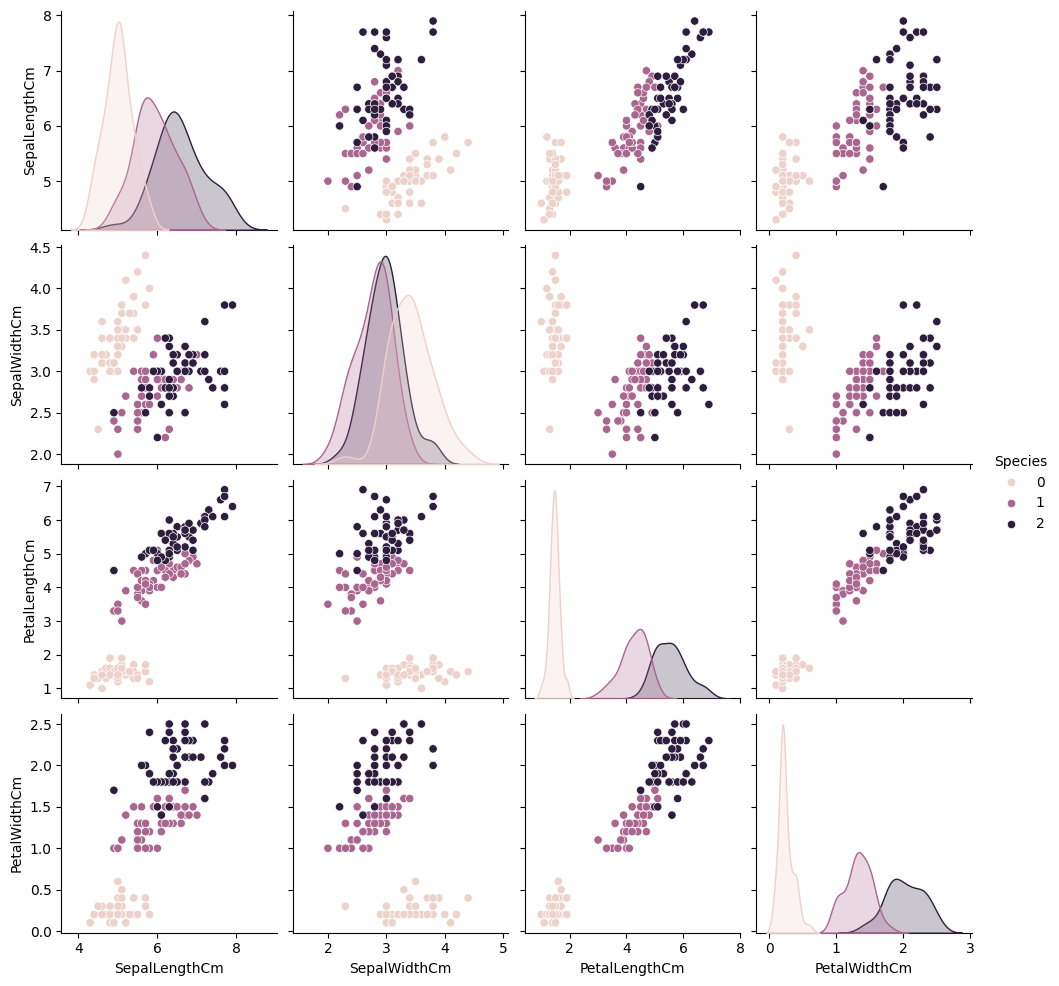

In [97]:
import seaborn as sns
sns.pairplot(df,hue="Species")

In [98]:
new_df = df[df['Species'] != 0][['SepalLengthCm','SepalWidthCm','Species']]

In [99]:
new_df.head(100)

,SepalLengthCm,SepalWidthCm,Species
50,7.0,3.2,1
51,6.4,3.2,1
52,6.9,3.1,1
53,5.5,2.3,1
54,6.5,2.8,1
...,...,...,...
145,6.7,3.0,2
146,6.3,2.5,2
147,6.5,3.0,2
148,6.2,3.4,2


In [100]:
X = new_df.iloc[:,0:2]
Y = new_df.iloc[:,-1]

print(X)
print(Y)

     SepalLengthCm  SepalWidthCm
50             7.0           3.2
51             6.4           3.2
52             6.9           3.1
53             5.5           2.3
54             6.5           2.8
..             ...           ...
145            6.7           3.0
146            6.3           2.5
147            6.5           3.0
148            6.2           3.4
149            5.9           3.0

[100 rows x 2 columns]
50     1
51     1
52     1
53     1
54     1
      ..
145    2
146    2
147    2
148    2
149    2
Name: Species, Length: 100, dtype: int64


In [101]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np


In [102]:
ml1 = LogisticRegression()
ml2 = KNeighborsClassifier()
ml3 = RandomForestClassifier()

estimators = [('lr',ml1),('kn',ml2),('rf',ml3)]


In [103]:
for estimator in estimators:
    x = cross_val_score(estimator[1],X,y=Y,cv=10,scoring='accuracy')
    print(estimator[0],np.round(np.mean(x),2))


lr 0.75
kn 0.59
rf 0.6


In [104]:
from sklearn.ensemble import VotingClassifier

In [105]:
vc = VotingClassifier(estimators=estimators)
x = cross_val_score(vc,X,y=Y,cv=10,scoring='accuracy')
print(np.round(np.mean(x),2))


0.66


In [106]:
vc = VotingClassifier(estimators=estimators,voting='soft')
x = cross_val_score(vc,X,y=Y,cv=10,scoring='accuracy')
print(np.round(np.mean(x),2))


0.65
